# Transformers (PyTorch)

A Transformer encoder block replaces recurrence entirely with **self-attention**:
every token attends to every other token in parallel (instead of step-by-step like
[`RNN`](../06_RNN)/[`LSTM`](../07_LSTM)/[`GRU`](../08_GRU)), using multiple attention
"heads" so it can capture several different relationships at once. We use PyTorch's
built-in `nn.TransformerEncoderLayer` (which internally uses `nn.MultiheadAttention`)
rather than writing the attention math by hand.

Same task as the rest of the sequence topics — newsgroup posts, **hockey vs.
space** — with token + learned positional embeddings feeding a single Transformer
encoder block, mean-pooled and classified.

In [1]:
import re
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.datasets import fetch_20newsgroups

torch.manual_seed(0)

categories = ["rec.sport.hockey", "sci.space"]
train = fetch_20newsgroups(subset="train", categories=categories,
                            remove=("headers", "footers", "quotes"))
test = fetch_20newsgroups(subset="test", categories=categories,
                          remove=("headers", "footers", "quotes"))
len(train.data), len(test.data), train.target_names

(1193, 793, ['rec.sport.hockey', 'sci.space'])

In [2]:
MAX_VOCAB = 5000
MAX_LEN = 150


def tokenize(text):
    return re.findall(r"[a-z]+", text.lower())


def prepare(dataset):
    """Tokenize and drop any document with zero real tokens (a handful of these
    newsgroup posts are empty after stripping headers/quotes) — an all-padding row
    would make the attention mask fully masked, which is undefined for softmax."""
    tokens = [tokenize(doc) for doc in dataset.data]
    keep = [i for i, t in enumerate(tokens) if len(t) > 0]
    return [tokens[i] for i in keep], dataset.target[keep]


train_tokens, train_targets = prepare(train)
test_tokens, test_targets = prepare(test)

counter = Counter(tok for toks in train_tokens for tok in toks)
vocab = {"<pad>": 0, "<unk>": 1}
for word, _ in counter.most_common(MAX_VOCAB - len(vocab)):
    vocab[word] = len(vocab)


def encode(tokens):
    ids = [vocab.get(t, vocab["<unk>"]) for t in tokens][:MAX_LEN]
    ids += [vocab["<pad>"]] * (MAX_LEN - len(ids))
    return ids


X_train = torch.tensor([encode(t) for t in train_tokens], dtype=torch.long)
X_test = torch.tensor([encode(t) for t in test_tokens], dtype=torch.long)
y_train = torch.tensor(train_targets, dtype=torch.float32).view(-1, 1)
y_test = torch.tensor(test_targets, dtype=torch.float32).view(-1, 1)

vocab_size = len(vocab)
X_train.shape, vocab_size

(torch.Size([1161, 150]), 5000)

In [3]:
class TransformerClassifier(nn.Module):
    def __init__(self, vocab_size, max_len, emb_dim=32, nhead=4, ff_dim=64):
        super().__init__()
        self.token_emb = nn.Embedding(vocab_size, emb_dim, padding_idx=0)
        self.pos_emb = nn.Embedding(max_len, emb_dim)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=emb_dim, nhead=nhead, dim_feedforward=ff_dim, batch_first=True
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=1)
        self.fc = nn.Linear(emb_dim, 1)

    def forward(self, x):
        positions = torch.arange(x.size(1), device=x.device).unsqueeze(0)
        h = self.token_emb(x) + self.pos_emb(positions)
        pad_mask = x == 0  # True = position to ignore
        h = self.encoder(h, src_key_padding_mask=pad_mask)
        keep = (~pad_mask).unsqueeze(-1).float()
        pooled = (h * keep).sum(dim=1) / keep.sum(dim=1)  # mean over real tokens only
        return self.fc(pooled)


model = TransformerClassifier(vocab_size, MAX_LEN)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.003)

In [4]:
losses = []
for epoch in range(40):
    optimizer.zero_grad()
    logits = model(X_train)
    loss = criterion(logits, y_train)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
    print(f"epoch {epoch+1:2d}  loss {loss.item():.4f}")

epoch  1  loss 0.6944


epoch  2  loss 0.6894


epoch  3  loss 0.6858


epoch  4  loss 0.6807


epoch  5  loss 0.6751


...

epoch 36  loss 0.1201


epoch 37  loss 0.1069


epoch 38  loss 0.0893


epoch 39  loss 0.0796


epoch 40  loss 0.0664


Test accuracy: 0.868


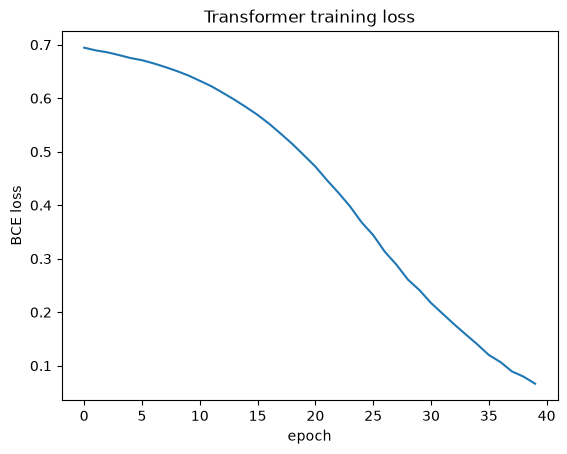

In [5]:
with torch.no_grad():
    preds = torch.sigmoid(model(X_test)) >= 0.5
    accuracy = (preds.float() == y_test).float().mean().item()
print(f"Test accuracy: {accuracy:.3f}")

plt.plot(losses)
plt.xlabel("epoch")
plt.ylabel("BCE loss")
plt.title("Transformer training loss")
plt.show()